# Portfolio problem

In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)


In [2]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

In [3]:
experiment_name = ExperimentName.kl_portfolio
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_portfolio")
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df["algorithm"].unique()

array(['kl_dro_bas', 'kl_bdro', 'kl_pp'], dtype=object)

In [4]:
# experiment_dir = Path("/dcs/large/u1508153/misdro/paper_bas/mmd_portfolio")
# assert experiment_dir.exists()
# kl_results_df = pd.read_csv(experiment_dir / "results.csv")
# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]
# kl_results_df = kl_results_df.loc[kl_results_df["replication"] < 2].set_index(["uuid", "replication"])
# results_df = pd.concat([results_df, kl_results_df])
# results_df["algorithm"].unique().tolist()

In [5]:
# NOTE filter by DGP
filter_dgp = "DowJones"
dataset = "portfolio"
# results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)
results_df["algorithm"].unique()

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# if "out_of_sample_costs" in results_df.columns:
#     results_df = results_df.rename(columns={"out_of_sample_costs": "out_of_sample_cost"})

# def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
#     if str_list == "[]":
#         return[np.nan for _ in range(list_len)]
#     else:
#         return [float(x) for x in str_list.strip('[]').split(',')]

# # NOTE we always want the same number of test observations
# assert np.isclose(results_df["num_test_observations"].var(), 0)
# num_test_observations = results_df["num_test_observations"].unique()[0]
# num_replications = results_df["num_replications"].unique()[0]
# results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# # the log partition constant should always be the same for BAS
# assert np.isclose(results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].var(), 0)
# log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]

# # special case for 1 test observation
# if num_test_observations == 1:
#     results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
# elif num_test_observations > 1 and dataset == "portfolio":
#     results_df["solution"] = results_df["solution"].map(lambda x: convert_str_to_float_list(x, num_test_observations))
# else:
#     raise NotImplementedError("Not supported yet!")


array(['kl_dro_bas', 'kl_bdro', 'kl_pp'], dtype=object)

In [6]:
# num_total_samples = []
# for _, row in all_results_df.iterrows():
#     if row["algorithm"] in ("kl_bdro", "kl_dro_bas"):
#         num_total_samples.append(row["num_posterior_samples"])
#     else:
#         raise NotImplementedError()
# results_df["num_total_samples"] = num_total_samples

# results_df["sample_time"] = results_df["likelihood_time"] + results_df["posterior_time"]
# gb = results_df.groupby(["algorithm", "num_total_samples"])
# solve_time_df = gb.agg(
#     mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
#     std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
#     mean_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.mean),
#     std_sample_time = pd.NamedAgg(column="sample_time", aggfunc=np.std),
# )
# solve_time_df = solve_time_df.round(decimals=4)
# solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
#     lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
# )
# solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
#     lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
# )
# print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())



In [7]:
# now only look at 30 posterior samples for BDRO
num_samples = 900
results_df = results_df.loc[(results_df["algorithm"] != "kl_bdro") | (results_df["num_posterior_samples"] == num_samples)]
results_df = results_df.loc[(results_df["algorithm"] != "kl_pp") | (results_df["num_likelihood_samples"] == num_samples)]

# results_df = results_df.loc[results_df["replication"] == ]

assert np.isclose(results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].var(), 0)
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]

agg_df = get_agg_df(results_df, gb_cols=["algorithm", "epsilon"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function mean at 0x7f8b18112340> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function std at 0x7f8b18112480> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  epsilon                                          
kl_bdro    0.00001            0.006798           0.002559   
           0.00002            0.006513           0.002447   
           0.00005            0.006380           0.002263   
           0.00010            0.006116           0.002113   
           0.00020            0.005596           0.001931   
           0.00050            0.005215           0.001584   
           0.00100            0.004752           0.001324   
           0.00200            0.004119           0.000996   
           0.00500            0.003279           0.000691   
           0.01000            0.002881           0.000583   
           0.02000            0.002655           0.000534   
           0.05000            0.002527           0.000506   
           0.10000            0.002473           0.000498   
           0.20000            0.002438           0.000493   
           0.50000            0.002408           0.000491   
           1.00000            0.002393           0.000491   
kl_dro_bas 0.00001            0.006878           0.002603   
           0.00002            0.006661           0.002518   
           0.00005            0.006415           0.002338   
           0.00010            0.006299           0.002216   
           0.00020            0.005980           0.002053   
           0.00050            0.005357           0.001773   
           0.00100            0.005070           0.001485   
           0.00200            0.004557           0.001208   
           0.00500            0.003604           0.000809   
           0.01000            0.003127           0.000641   
           0.02000            0.002775           0.000560   
           0.05000            0.002581           0.000516   
           0.10000            0.002504           0.000502   
           0.20000            0.002458           0.000496   
           0.50000            0.002420           0.000492   
           1.00000            0.002401           0.000491   
kl_pp      0.00001            0.003624           0.001797   
           0.00002            0.003652           0.001761   
           0.00005            0.003561           0.001598   
           0.00010            0.003367           0.001498   
           0.00020            0.003149           0.001409   
           0.00050            0.003112           0.001223   
           0.00100            0.002963           0.001007   
           0.00200            0.002794           0.000860   
           0.00500            0.002649           0.000698   
           0.01000            0.002513           0.000614   
           0.02000            0.002410           0.000564   
           0.05000            0.002317           0.000526   
           0.10000            0.002300           0.000509   
           0.20000            0.002297           0.000500   
           0.50000            0.002315           0.000495   
           1.00000            0.002340           0.000495   

                    sum_of_in_group_var  var_of_in_group_mean  \
algorithm  epsilon                                              
kl_bdro    0.00001             0.002376              0.000183   
           0.00002             0.002280              0.000167   
           0.00005             0.002109              0.000154   
           0.00010             0.001973              0.000141   
           0.00020             0.001802              0.000129   
           0.00050             0.001477              0.000108   
           0.00100             0.001233              0.000091   
           0.00200             0.000932              0.000064   
           0.00500             0.000649              0.000042   
           0.01000             0.000548              0.000035   
           0.02000             0.000502              0.000031   
           0.05000             0.000477              0.000029   
           0.10000             0.000469              0.0000

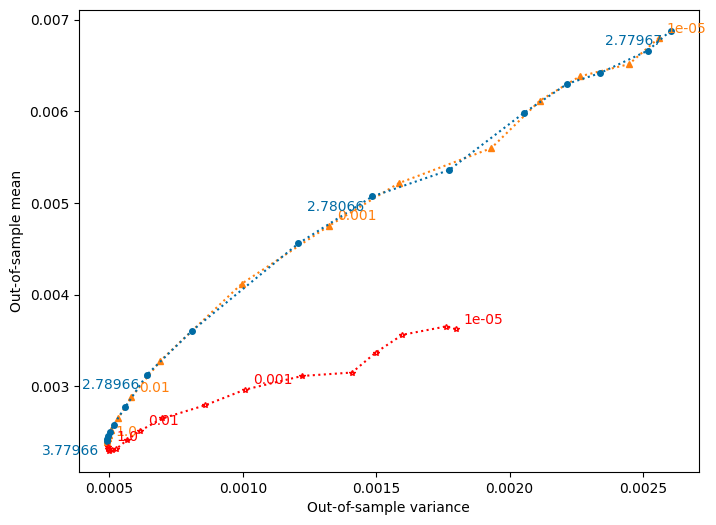

In [8]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for algorithm, group_df in df.groupby("algorithm"):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_inference_style(algorithm, "bayes"), special_epsilons=[0.00001, 0.001, 0.01, 1.0], add_log_partition_function=local_log_partition_constant)
    #  log_partition_constant=local_log_partition_constant
# handles, labels = ax.get_legend_handles_labels()
# order = [1,0]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend()
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_mean_var_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

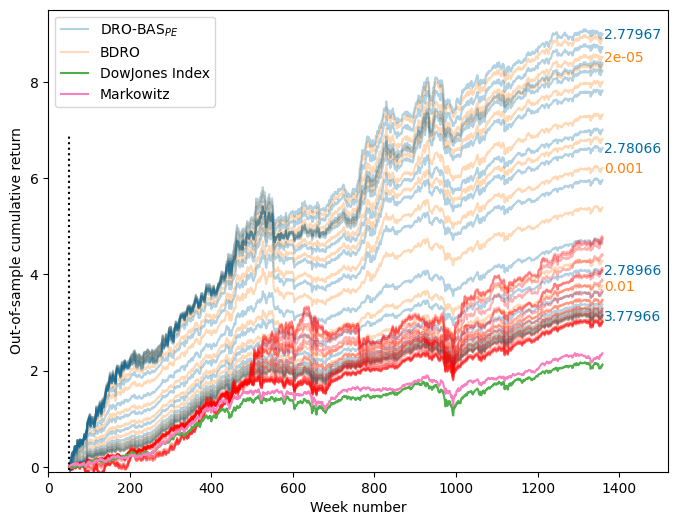

In [9]:
fig, ax = plt.subplots(figsize=(8,6))
num_replications = results_df["num_replications"].unique()[0]
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))
last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])
bdro_labelled = False
dro_bas_labelled = False
oos_week_numbers = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]
for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # dro_returns = group_df[week_cols].values.flatten()
    assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = AlgorithmName[algorithm].value
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = AlgorithmName[algorithm].value
        bdro_labelled = True
    else:
        label='_nolegend_'
    ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
    if algorithm == "kl_dro_bas" and epsilon in [0.00001, 0.001, 0.01, 1.0]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
        ax.text(last_week + IN_SAMPLE_TIME_WINDOW, np.cumsum(dro_returns)[last_week-4]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    ax.plot(oos_week_numbers, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(0, 1520)
ax.set_ylim(-0.1, 9.5)
ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
# ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend()
# plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()

In [10]:
bas_returns = []
bdro_returns = []
filter_epsilon = 0.1
for (algorithm, epsilon), group_df in gb:
    # dro_returns = group_df[week_cols].values.flatten()
    if algorithm == "kl_dro_bas" and epsilon == filter_epsilon:
        assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
        for i in range(num_replications):
            bas_returns += group_df["out_of_sample_cost"].values[i]
    if algorithm == "kl_bdro" and epsilon == filter_epsilon:
        assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
        for i in range(num_replications):
            bdro_returns += group_df["out_of_sample_cost"].values[i]
plt.hist(bas_returns, bins=50, label="BAS", alpha=0.5)
plt.hist(bdro_returns, bins=50, label="BDRO", alpha=0.5)
plt.legend()

NameError: name 'gb' is not defined

In [11]:
from mis_dro.dataset import portfolio_dataset

training_time_window_id = 72
out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW * 4
data, data_eval = portfolio_dataset("DowJones-crash", training_time_window_id, mmc2_dir, out_of_sample_time_window=out_of_sample_time_window)
dim = data.shape[1]
sol = np.ones(dim) / float(dim)
data.shape, data_eval.shape

((52, 28), (208, 28))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


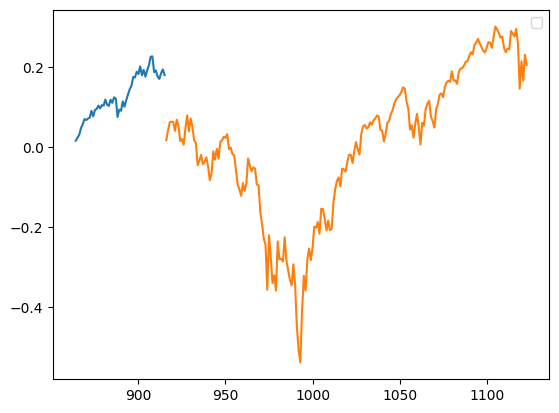

In [12]:
start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window
total_training_returns = (data @ sol).sum()

# plt.plot(oos_week_numbers[start_training_week:], np.cumsum(index_returns_df.iloc[start_training_week + IN_SAMPLE_TIME_WINDOW:IN_SAMPLE_TIME_WINDOW+OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values), label=f"{dgp} Index", color=CB_color_cycle[0])
plt.plot(oos_week_numbers[start_training_week - IN_SAMPLE_TIME_WINDOW:end_training_week - IN_SAMPLE_TIME_WINDOW], (data @ sol).cumsum())
plt.plot(oos_week_numbers[test_start - IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], (data_eval @ sol).cumsum())
plt.legend()
